# 03 - Deep Learning for Parkinson Detection

In this notebook, we build a neural network model to classify Parkinson’s disease from voice measurements.

The goal is to compare Deep Learning performance against the classical Machine Learning models trained in the previous notebook.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

## 1. Load the dataset

The dataset is loaded directly from GitHub to make the notebook reproducible in Colab.

In [4]:
url = "https://raw.githubusercontent.com/beatriangu/parkinson-ml-dl-voice-analysis/main/data/parkinsons.csv"

df = pd.read_csv(url)

df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [5]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (195, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               1

## 2. Prepare features and target

The `name` column is removed because it is only an identifier.  
The target variable is `status`, where:

- `0` = Healthy
- `1` = Parkinson

In [6]:
X = df.drop(["name", "status"], axis=1)
y = df["status"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (195, 22)
Target: (195,)


## 3. Train-test split and scaling

Neural networks are sensitive to feature scale, so all input variables are standardized using `StandardScaler`.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)

X_train: (156, 22)
X_test: (39, 22)


## 4. Build the neural network

We define a simple feedforward neural network for binary classification.

The final layer uses a sigmoid activation because the target has two possible classes: Healthy or Parkinson.

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile the model

We use:

- `binary_crossentropy` because this is a binary classification problem.
- `adam` as optimizer.
- `accuracy` as the first evaluation metric.

In [9]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 6. Train the model

We train the neural network using a validation split to monitor performance on unseen data during training.

In [10]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=80,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 248ms/step - accuracy: 0.7097 - loss: 0.6319 - val_accuracy: 0.7500 - val_loss: 0.5287
Epoch 2/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7581 - loss: 0.5623 - val_accuracy: 0.8125 - val_loss: 0.4879
Epoch 3/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7581 - loss: 0.5536 - val_accuracy: 0.8438 - val_loss: 0.4538
Epoch 4/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7742 - loss: 0.5465 - val_accuracy: 0.8750 - val_loss: 0.4252
Epoch 5/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7742 - loss: 0.5184 - val_accuracy: 0.9375 - val_loss: 0.4018
Epoch 6/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7903 - loss: 0.4898 - val_accuracy: 0.9688 - val_loss: 0.3831
Epoch 7/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7984 - loss: 0.4710 - val_accuracy: 0.9688 - val_loss: 0.3672
Epoch 8/80
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8065 - loss: 0.4645 - val_accuracy: 0.9688 - val_loss: 0.3524

## 7. Training curves

Training curves help us understand whether the neural network is learning correctly or overfitting.

We visualize both accuracy and loss for the training and validation sets.

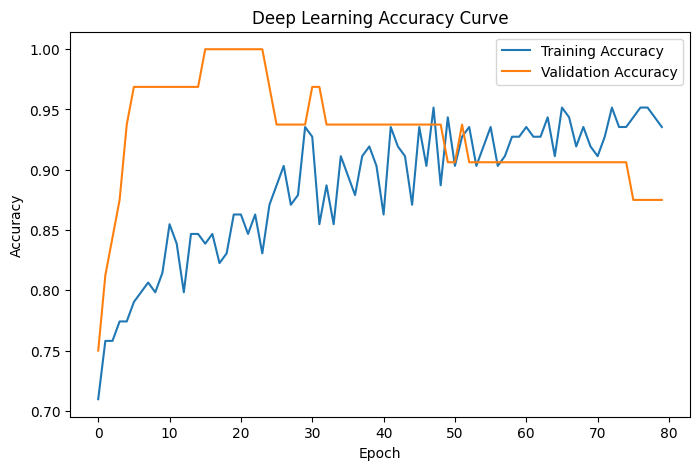

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Deep Learning Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig(
    "dl_accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

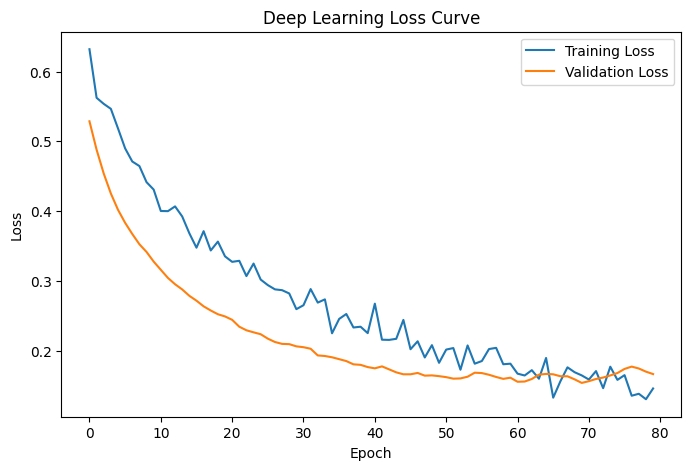

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Deep Learning Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig(
    "dl_loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 8. Evaluate the neural network

We evaluate the model on the test dataset using multiple classification metrics.

In [13]:
y_pred_prob = model.predict(X_test_scaled)

y_pred = (y_pred_prob > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 340ms/step


In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

Accuracy : 0.9487
Precision: 0.9655
Recall   : 0.9655
F1-score : 0.9655


In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.97      0.97      0.97        29

    accuracy                           0.95        39
   macro avg       0.93      0.93      0.93        39
weighted avg       0.95      0.95      0.95        39



## 9. Confusion Matrix

The confusion matrix helps visualize prediction errors and class performance.

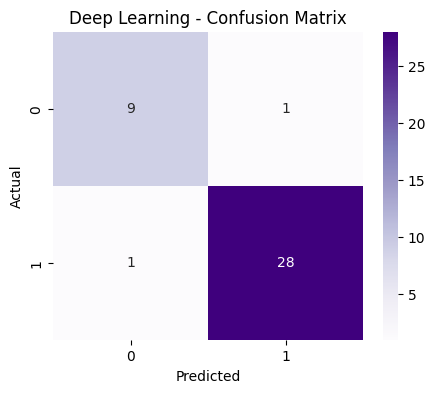

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Deep Learning - Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "dl_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Final Conclusions

This notebook explored a Deep Learning approach for Parkinson’s Disease detection using voice measurements.

### Main findings

- The neural network achieved strong classification performance on the test dataset.
- Voice biomarkers appear to contain highly predictive information for Parkinson detection.
- Deep Learning performed competitively against the classical Machine Learning models explored previously.

### Technical insights

- Feature scaling was essential for stable neural network training.
- Training and validation curves helped monitor overfitting behavior.
- Despite the small dataset size, the neural network generalized reasonably well.

### Comparison with Classical ML

- Classical Machine Learning models already achieved very strong performance.
- Deep Learning did not drastically outperform XGBoost, which is common in small tabular datasets.
- This project demonstrates that model complexity should always be adapted to dataset size and structure.

### Next steps

Future improvements could include:

- Hyperparameter tuning
- Cross-validation
- Larger datasets
- Voice spectrogram analysis
- CNN architectures for audio processing
- Real-world voice recordings